# Atmospheric neutrinos from a *measured* atmosphere

### NASA AIRS satellite temperatures → MCEq → the neutrino rate at IceCube

A pion (or kaon) born in a cosmic-ray shower has two futures: **decay** into a neutrino,
or **hit an air nucleus** first and make no neutrino at all. Which one wins is
decided by the density of the air around it — **warm air is thin, so more pions
decay and more neutrinos arrive; cold dense air means fewer.** A neutrino
telescope therefore cares what the weather is doing, and this
notebook calculates it with real satellite data.

## What you need to install

```bash
pip install MCEq requests xarray "numpy>=2" netcdf4 matplotlib cartopy
pip install 'git+https://github.com/afedynitch/nrlmsis2.1'
```

You also need a free [Earthdata Login](https://urs.earthdata.nasa.gov), with
*NASA GESDISC DATA ARCHIVE* approved under Applications → Authorized Apps.

In [1]:
import datetime
import gzip
import hashlib
import time
import netrc
import os
import urllib.parse

import matplotlib.pyplot as plt
import numpy as np
import requests
import xarray as xr

### Settings — everything you might want to change lives here

In [2]:
G0 = 9.80665 # gravity constant
R_D = 287.06 # gas constant of dry air

# One week of austral winter. Select to your liking.
START_DATE, END_DATE = "2013-08-05", "2013-08-11"

# This is the "Earth patch" we want to download data for.
# We take 360deg in longitude and cut in latitude.
LAT_RANGE = (-90.0, -35.0)

# The satellite passes overhead twice a day.
# A = Ascending
# D = Descending
# Explaination comes later
OVERPASSES = ("A", "D")

# Storage
CACHE_DIR = "airs_cache" # store AIRS downloads here
OUTPUT_DIR = "airs_tables" # store output table for MCEq here
SURFACE_TABLE = os.path.join(OUTPUT_DIR, "airs_surface.csv") # he we are going to store the Earth elevations

# IceCube
SITE_LON, SITE_LAT = 0.0, -90.0 # Location
SITE_ELEVATION_M = 2835.0 # Surface elevation
SITE_DEPTH_M = 1948.0 # Depth of detector
E_THRESHOLD = 100.0  # energy threshold approx for neutrinos, we do not have effective area here, so we integrate counts above this value
ZENITH_BAND = np.linspace(90.0, 115.0, 11)  # the up-going band, same band as https://arxiv.org/pdf/2303.04682

# Make this notebook FAST
# Use only every 3rd latitude and every 15th longitude of the data.
LAT_STRIDE, LON_STRIDE = 3, 15

## 1. The whole MCEq recipe, in 8 lines

MCEq solves the **coupled cascade equations**: it predicts the statistical average flux 
of a cosmic-ray air showers and tracks how many particles of each species and energy
are produced.

To run **these 8 lines** we need to **convert the AIRS data to .csv format**:

```python
import crflux.models as pm
import MCEq.geometry.density_profiles as dp
from MCEq.core import MCEqRun

# Load an AIRS (or other satellite) table
table = dp.AtmosphereTable.load_from_csv("my_atmosphere.csv.gz")

# Construct the Atmosphere with it
atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),   # lon, lat
                             surface_elevation_m=SITE_ELEVATION_M)     # where the ground is

# Build an MCEq instance
mceq = MCEqRun(interaction_model="SIBYLL2.3d",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=atm)
               
# Solve the Cascade Equations
mceq.solve()
flux = mceq.get_solution("total_numu")   # Flux, per cm^2 s sr GeV
```

The CSV is a plain text table of height, temperature and pressure — it can
come from **any** source. Here it comes from a satellite.

### The route from satellite data to a neutrino flux

findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.
findfont: Failed to find font weight semibold, now using 700.


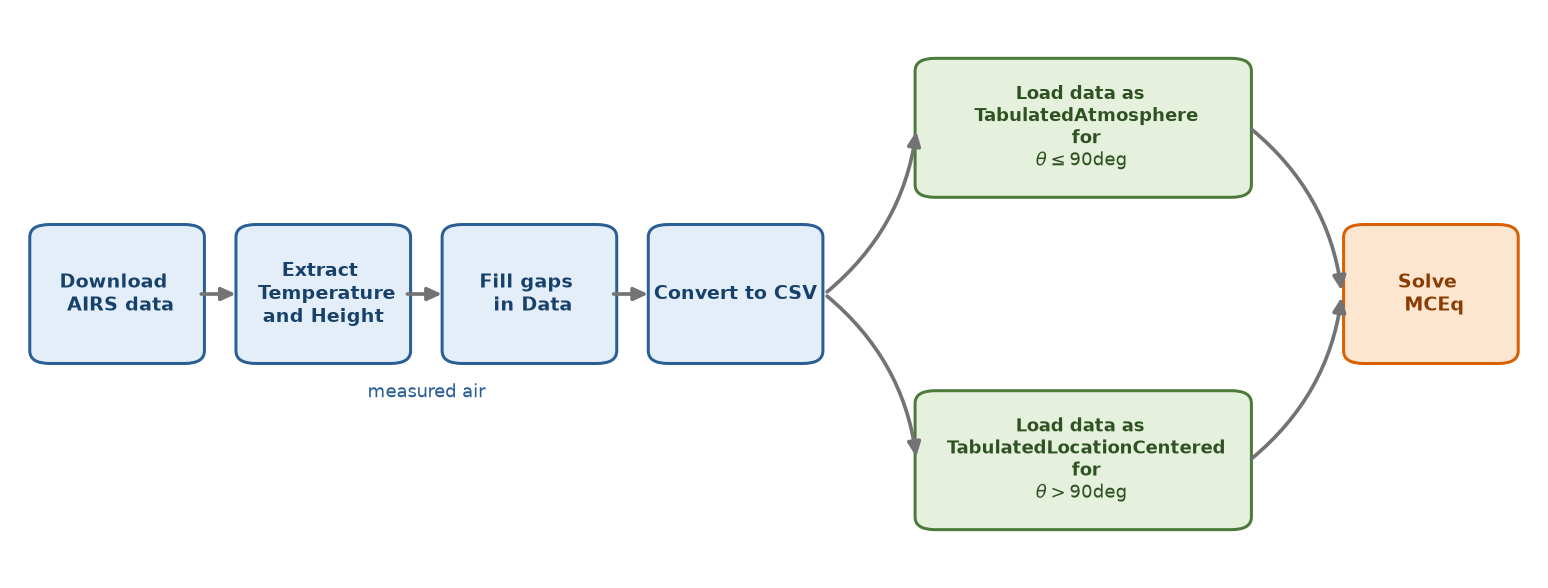

In [3]:
from matplotlib.patches import FancyBboxPatch

# Four steps to the table, then a fork: the direction you look decides which
# class reads it.  Every label is in words the reader already has.
chain = ["Download \n AIRS data", "Extract \n Temperature\nand Height",
         "Fill gaps \n in Data", "Convert to CSV"]
fork = [("Load data as \n TabulatedAtmosphere\n for\n" + r"$\theta \leq 90\deg$"),
        ("Load data as \n TabulatedLocationCentered\n for\n" + r"$\theta > 90\deg$")]

BW, GAP, BH = 0.20, 0.055, 0.26
fig, ax = plt.subplots(figsize=(13, 5.0), dpi=120)


def box(x, y, w, h, title, fc, ec, tc, ts=11.5):
    ax.add_patch(FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.008,rounding_size=0.025",
                                fc=fc, ec=ec, lw=1.8))
    ax.text(x + w / 2, y + h * 0.50, title, ha="center", va="center",
            fontsize=ts, color=tc, weight="semibold")


def arrow(x0, y0, x1, y1, rad=0.0):
    ax.annotate("", xy=(x1, y1), xytext=(x0, y0),
                arrowprops=dict(arrowstyle="-|>,head_width=0.32,head_length=0.7",
                                color="0.45", lw=2.2,
                                connectionstyle=f"arc3,rad={rad}"))


MID = 0.50
for k, title in enumerate(chain):
    x = k * (BW + GAP)
    box(x, MID - BH / 2, BW, BH, title, "#e3eef8", "#2a5f95", "#17416b")
    if k:
        arrow(x - GAP, MID, x - 0.004, MID)
CHAIN_END = 3 * (BW + GAP) + BW

FX, FW = CHAIN_END + 0.13, 0.40
for k, title in enumerate(fork):
    y = MID + 0.20 if k == 0 else MID - 0.20 - BH
    box(FX, y, FW, BH, title, "#e6f1dd", "#4b7a3a", "#2f5223", ts=11)
    arrow(CHAIN_END + 0.01, MID, FX - 0.006, y + BH / 2, rad=0.20 if k == 0 else -0.20)
    arrow(FX + FW + 0.006, y + BH / 2, FX + FW + 0.12, MID, rad=0.20 if k == 1 else -0.20)

MX = FX + FW + 0.13
box(MX, MID - BH / 2, BW, BH, "Solve \n MCEq", "#fce6d0", "#d95f02", "#8a3d02")

# Captions go under their own column, centred, so nothing lands on a box.
ax.text(CHAIN_END / 2, MID - BH / 2 - 0.075, "measured air", fontsize=10.5,
        color="#2a5f95", ha="center")
# ax.text(MX + BW / 2, MID - BH / 2 - 0.075, "what the detector sees", fontsize=10.5,
#         color="#d95f02", ha="center")
ax.set_xlim(-0.03, MX + BW + 0.03)
ax.set_ylim(MID - 0.20 - BH - 0.10, MID + 0.20 + BH + 0.10)
ax.axis("off")
fig.tight_layout()

## 2. What AIRS is

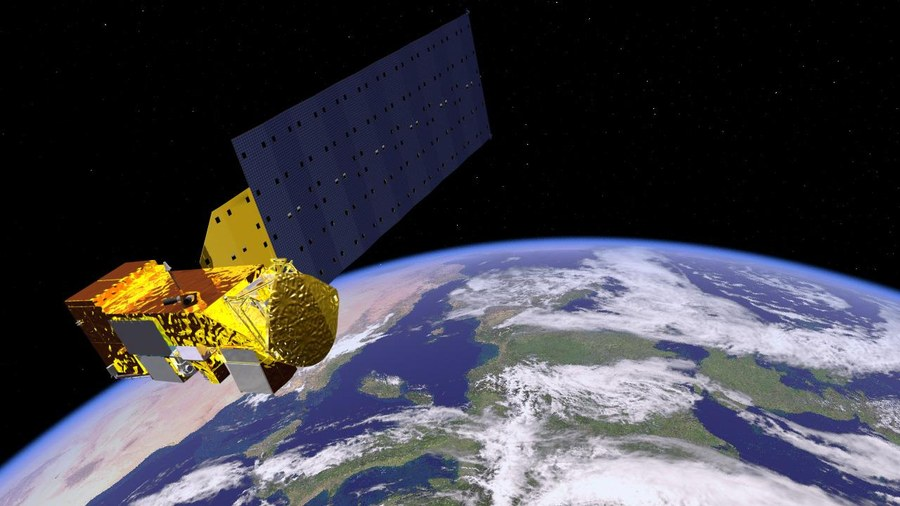

<sub>Artist's concept of NASA's **Aqua** spacecraft, which has carried AIRS since
2002. Image credit: NASA/JPL-Caltech
([PIA18156](https://www.jpl.nasa.gov/images/pia18156-aqua-satellite-orbiting-earth-artists-concept/)).</sub>

* **AIRS** — the Atmospheric Infrared Sounder — measures Earth's own infrared
  spectrum, and a infers the **temperature profile**.
* We use the daily gridded product `AIRS3STD` v7.0: temperature and
  geopotential height on **24 pressure levels** (1000 → 1 hPa), on a 1°×1° grid.
* $T$ and $p$ give density through the ideal gas law; geopotential height says
  at what **altitude** to put it. That is everything MCEq needs.

### The catch

Aqua's orbit is inclined 98.2°, so its ground track turns around at 81.8° and
**never crosses the pole**. Right where IceCube sits, AIRS looks least often.

Aqua crosses the equator twice a day, northbound ~13:30 and southbound ~01:30
local time. The product keeps the two passes as separate grids, **A** and **D**.

## 3. Getting the data

Again: You **need a free [Earthdata Login](https://urs.earthdata.nasa.gov)**, with
*NASA GESDISC DATA ARCHIVE* approved under Applications → Authorized Apps.

You **need to generate a token**.


Credentials are read from `$EARTHDATA_TOKEN`, then `~/.edl_token`. Place your token in either.

___Dangerous Fallback___:
Place your username and password in `~/.netrc` as "urs.earthdata.nasa.gov < username > < password >".

It is **highly recommend** to **not place your plain passwords anywhere**. Use the token option.


### These are just helpers for downlaoding

In [4]:
# Plumbing: log in, ask NASA's catalogue for file names, GET one cached
# subset.  Nothing here is about atmospheres -- skip to the next cell.
CMR = "https://cmr.earthdata.nasa.gov/search/granules.json"
OPENDAP = "https://acdisc.gesdisc.eosdis.nasa.gov/opendap/Aqua_AIRS_Level3/AIRS3STD.7.0"


class EarthdataSession(requests.Session):
    """Keeps the Authorization header across the Earthdata Login redirect."""

    def rebuild_auth(self, request, response):
        # requests drops the header when a redirect changes host.  Right
        # everywhere else, wrong here, because the login lives on another host.
        if "Authorization" in request.headers:
            hosts = {urllib.parse.urlparse(u).hostname
                     for u in (response.request.url, request.url)}
            if len(hosts) > 1 and "urs.earthdata.nasa.gov" not in hosts:
                del request.headers["Authorization"]


def login():
    """A session authenticated by bearer token, or by ~/.netrc."""
    session = EarthdataSession()
    token = os.environ.get("EARTHDATA_TOKEN", "").strip()
    if not token and os.path.exists(os.path.expanduser("~/.edl_token")):
        token = open(os.path.expanduser("~/.edl_token")).read().strip()
    if token:
        session.headers["Authorization"] = f"Bearer {token}"
        return session
    try:
        user, _, password = netrc.netrc().authenticators("urs.earthdata.nasa.gov")
    except (FileNotFoundError, TypeError):
        raise RuntimeError(
            "No Earthdata credentials: set $EARTHDATA_TOKEN, write ~/.edl_token, "
            "or add urs.earthdata.nasa.gov to ~/.netrc."
        )
    session.auth = (user, password)
    return session


def find_granules(start, end):
    """{date: OPeNDAP url} for the AIRS3STD granules covering the dates."""
    reply = requests.get(CMR, timeout=60, params={
        "short_name": "AIRS3STD", "version": "7.0", "page_size": 200,
        "temporal": f"{start}T00:00:00Z,{end}T23:59:59Z"}).json()
    out = {}
    for entry in reply["feed"]["entry"]:
        name = entry["title"].split(":")[-1]      # ...AIRS.2013.08.05.L3....hdf
        year, month, day = name.split(".")[1:4]
        date = f"{year}-{month}-{day}"
        if start <= date <= end:
            out[date] = f"{OPENDAP}/{year}/{name}"
    return dict(sorted(out.items()))


def fetch(session, url, constraint):
    """Download one server-side subset, cached on the constraint's hash."""
    os.makedirs(CACHE_DIR, exist_ok=True)
    tag = hashlib.sha1(constraint.encode()).hexdigest()[:8]
    path = os.path.join(CACHE_DIR, url.rsplit("/", 1)[-1].replace(".hdf", f".{tag}.nc4"))
    if not os.path.exists(path):
        reply = session.get(f"{url}.nc4?{urllib.parse.quote(constraint, safe='[]:,.')}",
                            timeout=900)
        reply.raise_for_status()
        with open(path + ".part", "wb") as out:      # never leave a half file
            out.write(reply.content)
        os.replace(path + ".part", path)
    return path

### This is the data access!

In [5]:
# Start a session
session = login()

# Find the data file given our Dates
granules = find_granules(START_DATE, END_DATE)

# Access the first file to get longitude, latitude,
# and the pressure levels
axes_path = fetch(session, next(iter(granules.values())),
                  "Latitude,Longitude,StdPressureLev")
with xr.open_dataset(axes_path) as axes:
    native_lat = axes["Latitude"].values.astype(float)
    n_lon = axes["Longitude"].size
    p_hpa_native = axes["StdPressureLev"].values.astype(float)

# Generate the mask according to the patch we want
rows = np.flatnonzero((native_lat >= LAT_RANGE[0]) & (native_lat <= LAT_RANGE[1]))
# start and end row for out lat range
J0, J1 = int(rows.min()), int(rows.max()) 

# Here we generate the "Request/Constraint String" for the data we want:
# Temperature and height for both passes, the
# terrain (elevation), and how many times AIRS measured each cell.
FIELDS = [f"{name}_{pas}" for pas in OVERPASSES for name in ("Temperature", "GPHeight")]
SURFACE = ["Topography", "TotalCounts_A", "TotalCounts_D"]
constraint = ",".join(
    [f"{n}[0:{p_hpa_native.size - 1}][{J0}:{J1}][0:{n_lon - 1}]" for n in FIELDS]
    + [f"{n}[{J0}:{J1}][0:{n_lon - 1}]" for n in SURFACE]
    + [f"Latitude[{J0}:{J1}]", f"Longitude[0:{n_lon - 1}]",
       f"StdPressureLev[0:{p_hpa_native.size - 1}]"])

print("This is how the generate constraint string looks like:\n", constraint)

paths = {date: fetch(session, url, constraint) for date, url in granules.items()}
total = sum(os.path.getsize(p) for p in paths.values())
print("We end up with: ", f"{len(paths)} granules, {total / 1e6:.0f} MB ")

This is how the generate constraint string looks like:
 Temperature_A[0:23][125:179][0:359],GPHeight_A[0:23][125:179][0:359],Temperature_D[0:23][125:179][0:359],GPHeight_D[0:23][125:179][0:359],Topography[125:179][0:359],TotalCounts_A[125:179][0:359],TotalCounts_D[125:179][0:359],Latitude[125:179],Longitude[0:359],StdPressureLev[0:23]
We end up with:  7 granules, 20 MB 


**Let's open one of the granules we downloaded!**

In [6]:
xr.open_dataset(paths[START_DATE])

<xarray.Dataset> Size: 8MB
Dimensions:         (Latitude: 55, Longitude: 360, StdPressureLev: 24)
Coordinates:
  * Latitude        (Latitude) float64 440B -35.0 -36.0 -37.0 ... -88.0 -89.0
  * Longitude       (Longitude) float64 3kB -180.0 -179.0 -178.0 ... 178.0 179.0
  * StdPressureLev  (StdPressureLev) float32 96B 1e+03 925.0 850.0 ... 1.5 1.0
Data variables:
    TotalCounts_A   (Latitude, Longitude) float32 79kB ...
    Temperature_A   (StdPressureLev, Latitude, Longitude) float32 2MB ...
    GPHeight_A      (StdPressureLev, Latitude, Longitude) float32 2MB ...
    TotalCounts_D   (Latitude, Longitude) float32 79kB ...
    Temperature_D   (StdPressureLev, Latitude, Longitude) float32 2MB ...
    GPHeight_D      (StdPressureLev, Latitude, Longitude) float32 2MB ...
    Topography      (Latitude, Longitude) float32 79kB ...
Attributes: (12/420)
    HDFEOSVersion:                                        HDFEOS_V2.18
    identifier_product_doi:                               10.5067/UO3Q64CTTS1U
    identifier_product_doi_authority:                     http://dx.doi.org/
    history:                                              2026-09-11 16:15:46...
    history_json:                                         [{"$schema":"https:...
    ascending._FV_TotalCounts_A:                          -9999.0
    ...                                                   ...
    location.H2OPressureLev:                              1000.0
    location.H2OPressureLay:                              961.7692
    location.EmisFreqIR:                                  832.0
    location.EmisFreqMW:                                  23.8
    location.CoarseCloudLayer:                            865.0
    location.FineCloudLayer:                              1018.0

Next we write a helper to access a single day of data:

In [7]:
def load_day(path):
    """One granule on ascending-latitude, [0,360) longitude axes."""
    with xr.open_dataset(path) as ds:
        lat = ds["Latitude"].values.astype(float)
        lon = ds["Longitude"].values.astype(float) % 360.0
        fields = {n: np.moveaxis(ds[n].values.astype(float), 0, -1)
                  for n in FIELDS}
        fields.update({n: ds[n].values.astype(float) for n in SURFACE})
    order_lat, order_lon = np.argsort(lat), np.argsort(lon)
    for name, value in fields.items():
        value = value[np.ix_(order_lat, order_lon)]
        # -9999 is AIRS's fill value and not every field declares it.
        fields[name] = np.where(value <= -9998.0, np.nan, value)
    return lat[order_lat], lon[order_lon], fields


# Levels ascending in height, i.e. descending in pressure.
level_order = np.argsort(p_hpa_native)[::-1]
p_hpa = p_hpa_native[level_order]

lat, lon, first = load_day(paths[START_DATE])
elevation_m = np.nan_to_num(first["Topography"], nan=0.0)

print(f"{lat.size} x {lon.size} columns, {p_hpa.size} levels "
      f"({p_hpa[0]:g} to {p_hpa[-1]:g} hPa)")
print(f"elevation {elevation_m.min():.0f} to {elevation_m.max():.0f} m")

55 x 360 columns, 24 levels (1000 to 1 hPa)
elevation 0 to 4033 m


### Where AIRS actually looked

Every cell of the AIRS grid, coloured by **how many times AIRS measured it that
day**. Red means it was never measured at all on this pass.

Aqua's ground track stops at 81.8 deg, but its scan reaches sideways past that,
so the cap is thinly covered rather than empty.

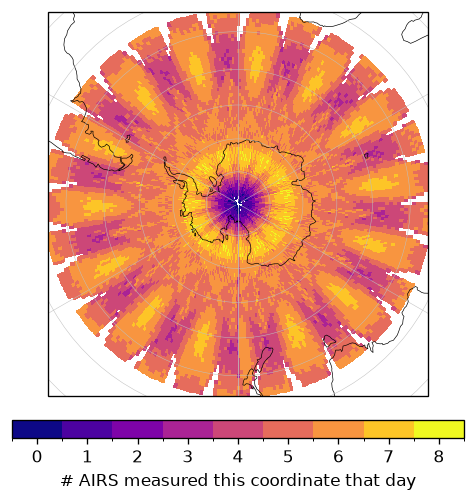

In [52]:
import cartopy.crs as ccrs
from matplotlib.colors import BoundaryNorm

polar = ccrs.SouthPolarStereo()


def polar_map(ax, field, lat, lon, cmap, label, quant_cmap=True):
    """A lon/lat field on a south polar stereographic map."""
    lon_closed = np.append(lon, lon[0] + 360.0)     # close the 0/360 seam
    field_closed = np.concatenate([field, field[:, :1]], axis=1)

    if quant_cmap:
        vmin = int(np.nanmin(field_closed))
        vmax = int(np.nanmax(field_closed))
        n_colors = vmax - vmin + 1
        base_cmap = plt.get_cmap(cmap, n_colors)
        bounds = np.arange(vmin - 0.5, vmax + 1.5, 1)
        norm = BoundaryNorm(bounds, base_cmap.N)
        ticks = np.arange(vmin, vmax + 1)
    else:
        base_cmap = cmap
        norm = None
        ticks = None
    
    mesh = ax.pcolormesh(lon_closed, lat, field_closed, cmap=base_cmap, norm=norm,
                         shading="auto", transform=ccrs.PlateCarree())
    ax.coastlines(lw=0.4)
    ax.gridlines(lw=0.3, color="0.75")
    ax.set_extent([-180, 180, *LAT_RANGE], ccrs.PlateCarree())
    plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.05, shrink=0.9,
                 aspect=25, label=label, ticks=ticks)
    return mesh


never_a = first["TotalCounts_A"] == 0
never_d = first["TotalCounts_D"] == 0

fig = plt.figure(figsize=(5.4, 5.2), dpi=120)
ax = fig.add_subplot(projection=polar)
total_passes = np.where(never_a, np.nan, first["TotalCounts_A"]) + np.where(never_d, np.nan, first["TotalCounts_D"])
polar_map(ax, total_passes, lat, lon,
          "plasma", "# AIRS measured this coordinate that day")

## 4. Filling the gaps

AIRS is a *measurement*, not a model: it reports a level only where the
retrieval worked. Cloud blocks it, and levels below the terrain do not exist.

MCEq needs **all levels in every column down to surface**, so the holes must be filled first.

Four rules do it, drawn below in order of **how much each one invents**.

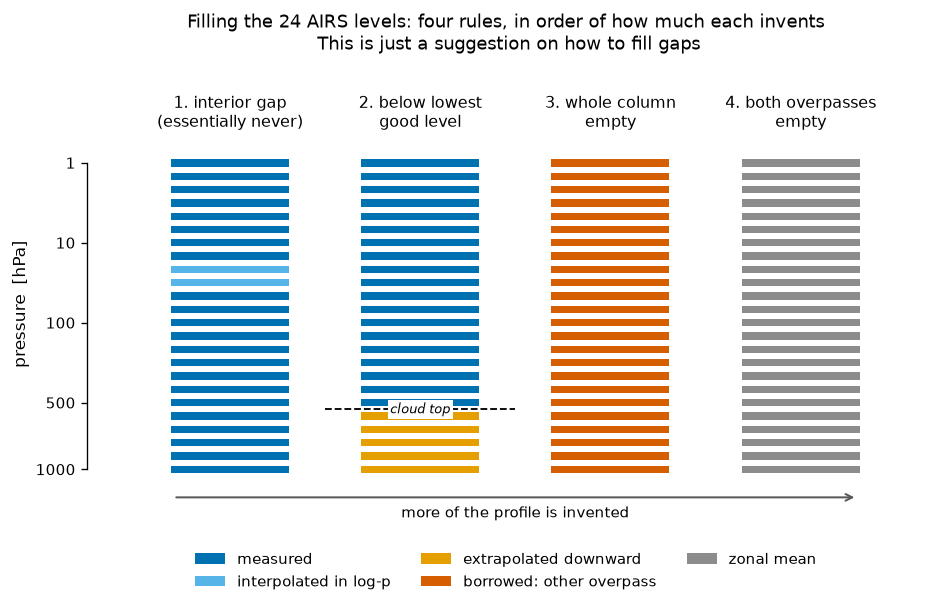

In [9]:
from matplotlib.patches import Patch

P = np.array([1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100,
              70, 50, 30, 20, 15, 10, 7, 5, 3, 2, 1.5, 1.0])   # 24 AIRS levels

# colour ramp: how much of the level is invented
COLOR = {"m": "#0072B2", "i": "#56B4E9", "x": "#E69F00", "b": "#D55E00", "z": "#8c8c8c"}
LABEL = {"m": "measured", "i": "interpolated in log-p", "x": "extrapolated downward",
         "b": "borrowed: other overpass", "z": "zonal mean"}

cols = [list("m" * 24), list("m" * 24), list("b" * 24), list("z" * 24)]
cols[0][14] = cols[0][15] = "i"       # 1: interior gap, good levels above and below
cols[1][0:5] = list("x" * 5)          # 2: nothing seen below the terrain / cloud
titles = ["1. interior gap\n(essentially never)", "2. below lowest\ngood level",
          "3. whole column\nempty", "4. both overpasses\nempty"]

fig, ax = plt.subplots(figsize=(9, 4.5), dpi=120)
for k, col in enumerate(cols):
    for i, s in enumerate(col):
        ax.barh(i, 0.62, left=k - 0.31, height=0.55, color=COLOR[s])
    ax.text(k, 25.3, titles[k], ha="center", va="bottom", fontsize=9.5)

ax.plot([0.5, 1.5], [4.5, 4.5], "k--", lw=1.1)
ax.text(1.0, 4.5, "cloud top", fontsize=8, style="italic", ha="center",
        va="center", bbox=dict(fc="white", ec="none", pad=1.5))
ax.annotate("", xy=(3.3, -2.1), xytext=(-0.3, -2.1),
            arrowprops=dict(arrowstyle="->", color="0.35", lw=1.2))
ax.text(1.5, -3.6, "more of the profile is invented", fontsize=9, ha="center")

ax.set_yticks([0, 5, 11, 17, 23], [f"{p:g}" for p in P[[0, 5, 11, 17, 23]]], fontsize=9)
ax.set_ylabel("pressure  [hPa]", fontsize=10)
ax.set_xticks([])
ax.set_xlim(-0.75, 3.65)
ax.set_ylim(-3.2, 28.0)
ax.spines["left"].set_bounds(0, 23)
for side in ("top", "right", "bottom"):
    ax.spines[side].set_visible(False)
ax.set_title("Filling the 24 AIRS levels: four rules, in order of how much each invents\n This is just a suggestion on how to fill gaps",
             fontsize=11, pad=28)
ax.legend(handles=[Patch(fc=COLOR[s], label=LABEL[s]) for s in "mixbz"],
          loc="lower center", bbox_to_anchor=(0.5, -0.22), ncol=3, frameon=False, fontsize=9)

**Next we implement the filling of gaps:**

In [24]:
# just some tags to check what happened to which data later
MEASURED, INTERIOR_GAP, OTHER_OVERPASS, EXTRAPOLATE, ZONAL_MEAN = 0, 1, 2, 3, 4
SOURCE_NAMES = {MEASURED: "measured", INTERIOR_GAP: "interpolate", EXTRAPOLATE: "extrapolate", OTHER_OVERPASS: "other overpass",
                ZONAL_MEAN: "zonal mean"}

def fill_gaps(t_k, gph_m, other):
    """
    Fill every column to all 24 levels.

    Input:
    t_k: Temperature at (lat, lon, pressure level)
    gph_m: Geopotential Height
    other: tuple (t_k, gph_m) for the other overpass, e.g. "D"

    Returns:
    (T, height, source)
    """
    n_lat, n_lon, n_lev = t_k.shape
    t, gph = t_k.copy(), gph_m.copy()
    good = np.isfinite(t) & np.isfinite(gph)
    source = np.full((n_lat, n_lon), MEASURED, np.int8) # logging in a map what we did to each coordinate

    # Rule 3 runs first.
    # The borrowed column then gets rules 1 and 2.
    # They are NOT averaged together: the two passes are about twelve hours
    # apart, so combining them would smear the day/night difference we want to keep (for now).
    # You might want to average, or fill gaps differently! Up to your taste.

    # missing data
    empty = ~good.any(axis=-1)
    # this finds the gapless data in the other pass
    usable = np.isfinite(other[0]) & np.isfinite(other[1]) 
    # fill where we can
    rescued = empty & usable.any(axis=-1)
    t[rescued], gph[rescued] = other[0][rescued], other[1][rescued]
    source[rescued] = OTHER_OVERPASS
    good = np.isfinite(t) & np.isfinite(gph)

    x = -np.log(p_hpa)                       # increases with height
    for j, i in zip(*np.nonzero(good.any(axis=-1))):
        levels = np.flatnonzero(good[j, i])
        low, high = levels[0], levels[-1]

        # Rule 1: interior gaps, interpolated in log pressure.
        inside = ~good[j, i]
        inside[:low] = False              # below the lowest good level
        inside[high + 1:] = False         # above the highest
        if inside.any():
            t[j, i, inside] = np.interp(x[inside], x[levels], t[j, i, levels])
            gph[j, i, inside] = np.interp(x[inside], x[levels], gph[j, i, levels])
            source[j, i] = INTERIOR_GAP

        # Rule 2: we just hold T constant
        if low > 0:
            for k in range(low - 1, -1, -1):
                t[j, i, k] = t[j, i, k + 1]
                gph[j, i, k] = gph[j, i, k + 1] - R_D / G0 * t[j, i, k] * np.log(
                    p_hpa[k] / p_hpa[k + 1])
            source[j, i] = EXTRAPOLATE
        # if high < n_lev - 1:
        #     for k in range(high + 1, n_lev):
        #         t[j, i, k] = t[j, i, k - 1]
        #         gph[j, i, k] = gph[j, i, k - 1] + R_D / G0 * t[j, i, k] * np.log(
        #             p_hpa[k - 1] / p_hpa[k])
        #     source[j, i] = EXTRAPOLATE

        
    # Rule 4
    # We take the mean of the latitude row. 
    # Again: You might want to spend more time in your own analysis in better interpolation.
    empty = ~good.any(axis=-1)
    for j in np.flatnonzero(empty.any(axis=-1)):
        assert (~empty[j]).any(), (
            f"latitude row {j} is empty in both passes, so there is nothing to "
            "average; widen LAT_RANGE or pick another day")
        t[j, empty[j]] = t[j, ~empty[j]].mean(axis=0)
        gph[j, empty[j]] = gph[j, ~empty[j]].mean(axis=0)
        source[j, empty[j]] = ZONAL_MEAN

    return t, gph, source

Let's test it for one day:

Text(0.5, 1.0, 'provenance, on the full 1$^\\circ$ grid')

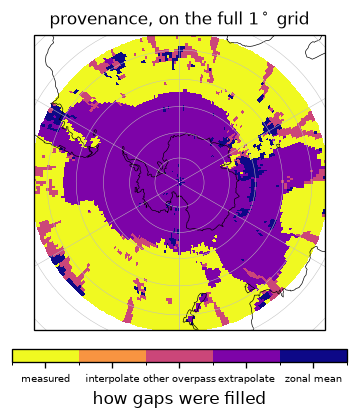

In [25]:
_, _, fields = load_day(paths[START_DATE])
raw = {p: (fields[f"Temperature_{p}"][..., level_order],
           fields[f"GPHeight_{p}"][..., level_order]) for p in OVERPASSES}
t_k, gph_m, source = fill_gaps(*raw['A'], raw['D'])

fig = plt.figure(figsize=(4, 4), dpi=120)
ax = fig.add_subplot(1, 1, 1, projection=polar)
mesh = polar_map(ax, source.astype(float), lat, lon,   
                "plasma_r",
                 "how gaps were filled")

mesh.colorbar.set_ticks(list(SOURCE_NAMES))
mesh.colorbar.set_ticklabels(list(SOURCE_NAMES.values()), fontsize=6)
ax.set_title("provenance, on the full 1$^\\circ$ grid", fontsize=10)

## 5. The table MCEq reads

A plain CSV. **Nothing in it is specific to AIRS** — this is the interface.

```
# MCEq tabulated atmosphere v1
lat_deg,lon_deg,h_cm,T_K,p_hPa
-89.0,0.0,283400.0,247.1,681.2
-89.0,0.0,510000.0,231.4,500.0
```

* `h_cm` — height above sea level.
* `T_K`, `p_hPa` — density follows from the ideal gas law.
* `lat_deg`, `lon_deg` — optional; they turn one column into a **grid** of
  them, one row per node and level.

One extra node is added at the pole, because AIRS's grid stops at −89° while
IceCube sits at −90°. At a pole every meridian meets, so its profile is the
mean of the −89° row over longitude.

In [63]:
def write_table(path, lat, lon, h_cm, t_k, p_hpa):
    """Write one gridded MCEq atmosphere table, one row per node and level."""
    n_lat, n_lon, n_lev = h_cm.shape
    rows = np.column_stack([
        np.repeat(lat, n_lon * n_lev), np.tile(np.repeat(lon, n_lev), n_lat),
        h_cm.reshape(-1), t_k.reshape(-1), np.tile(p_hpa, n_lat * n_lon)])
    with gzip.open(path, "wt", compresslevel=1) as out:
        out.write("# MCEq tabulated atmosphere v1\nlat_deg,lon_deg,h_cm,T_K,p_hPa\n")
        np.savetxt(out, rows, delimiter=",", fmt="%.4f,%.4f,%.6e,%.3f,%.6g")


def add_pole(lat, h_cm, t_k):
    """Add a node at -90: the mean of the southernmost row over longitude."""
    shape = (1,) + h_cm.shape[1:]
    return (np.concatenate([[-90.0], lat]),
            np.concatenate([np.broadcast_to(h_cm[0].mean(axis=0), shape), h_cm]),
            np.concatenate([np.broadcast_to(t_k[0].mean(axis=0), shape), t_k]))


os.makedirs(OUTPUT_DIR, exist_ok=True)
np.savetxt(SURFACE_TABLE, np.column_stack([
    np.repeat(lat, lon.size), np.tile(lon, lat.size), elevation_m.reshape(-1)]),
    delimiter=",", fmt="%.4f,%.4f,%.2f",
    header="lat_deg,lon_deg,h_surface_m", comments="")

table_files, column_source, map_temperature = {}, {}, {}
MAP_LEVEL = int(np.argmin(np.abs(p_hpa - 100.0)))
for date, path in paths.items():
    _, _, fields = load_day(path)
    raw = {p: (fields[f"Temperature_{p}"][..., level_order],
               fields[f"GPHeight_{p}"][..., level_order]) for p in OVERPASSES}
    for pas in OVERPASSES:
        other = raw["D" if pas == "A" else "A"]
        t_k, gph_m, source = fill_gaps(*raw[pas], other)

     
        # The region and the filling rules are in the name, so a re-run with
        # different settings writes new files instead of reusing old ones.
        tag = hashlib.sha1(f"{LAT_RANGE}".encode()).hexdigest()[:6]
        out_path = os.path.join(OUTPUT_DIR, f"airs_{date}_{pas}_{tag}.csv.gz")
        if not os.path.exists(out_path):
            pole_lat, h_cm, pole_t = add_pole(lat, gph_m * 100.0, t_k)
            write_table(out_path, pole_lat, lon, h_cm, pole_t, p_hpa)
        table_files[(date, pas)] = out_path
        column_source[(date, pas)] = source
        map_temperature[(date, pas)] = t_k[..., MAP_LEVEL] # store test temperatur
    print(f"{date} A pass  " + "  ".join(
        f"{name} {np.mean(column_source[(date, 'A')] == value):.0%}"
        for value, name in SOURCE_NAMES.items()))

2013-08-05 A pass  measured 28%  interpolate 0%  extrapolate 64%  other overpass 4%  zonal mean 4%
2013-08-06 A pass  measured 28%  interpolate 0%  extrapolate 65%  other overpass 4%  zonal mean 4%
2013-08-07 A pass  measured 33%  interpolate 0%  extrapolate 61%  other overpass 3%  zonal mean 3%
2013-08-08 A pass  measured 30%  interpolate 0%  extrapolate 63%  other overpass 4%  zonal mean 3%
2013-08-09 A pass  measured 29%  interpolate 0%  extrapolate 64%  other overpass 4%  zonal mean 3%
2013-08-10 A pass  measured 27%  interpolate 0%  extrapolate 66%  other overpass 4%  zonal mean 3%
2013-08-11 A pass  measured 28%  interpolate 0%  extrapolate 64%  other overpass 4%  zonal mean 4%


## 6. Driving MCEq with the table

You built the CSV in Part 5. Handing it to MCEq is three lines:

```python
table = dp.AtmosphereTable.load_from_csv(table_files[(START_DATE, "A")])
atm = dp.TabulatedAtmosphere(table, coord=(lon, lat), surface_elevation_m=2835)
```

⚠️ A `TabulatedAtmosphere` uses **the same column for every direction**. That is
exact straight up, but at large zenith angles the shower drifts hundreds of
kilometres downrange — then you want `TabulatedLocationCentered`

Now we look at the measured AIRS column at the pole against **NRLMSISE-21**, the
climatology MCEq ships with.

AtmosphereTable(grid 56x360, 24 levels, lat -90.00..-35.00, lon 0.00..359.00)
vertical column depth: AIRS 687, NRLMSISE-00 689 g/cm^2 (-0.3%)


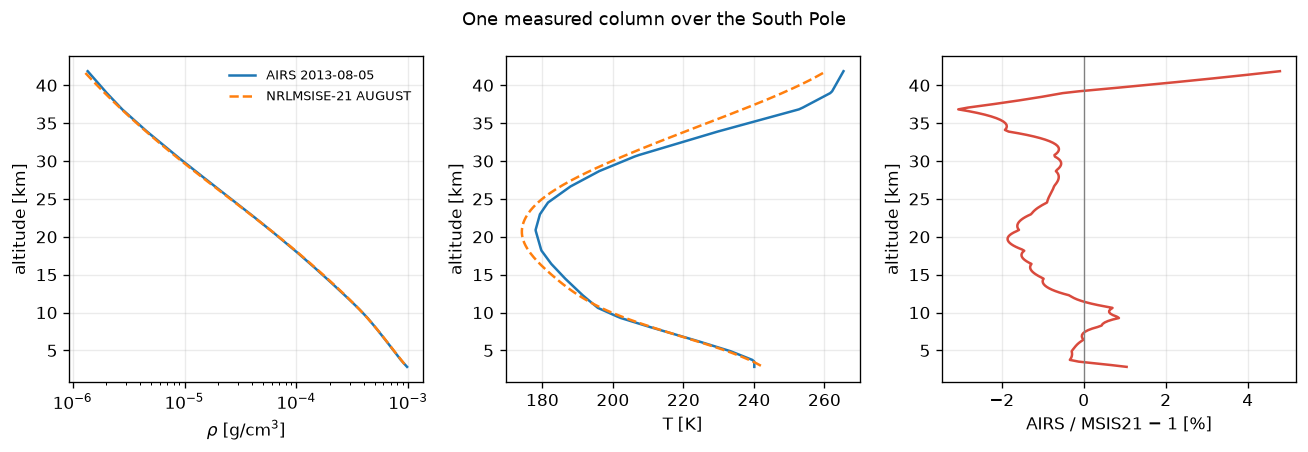

In [32]:
import MCEq.geometry.density_profiles as dp

first_key = (START_DATE, "A")
table = dp.AtmosphereTable.load_from_csv(table_files[first_key])
print(table)

airs_atm = dp.TabulatedAtmosphere(table, coord=(SITE_LON, SITE_LAT),
                                  surface_elevation_m=SITE_ELEVATION_M)
msis_atm = dp.MSIS21IceCubeCentered("SouthPole", "August")
for atm in (airs_atm, msis_atm):
    atm.set_theta(0.0)

print(f"vertical column depth: AIRS {airs_atm.max_X:.0f}, "
      f"NRLMSISE-00 {msis_atm.max_X:.0f} g/cm^2 "
      f"({100 * (airs_atm.max_X / msis_atm.max_X - 1):+.1f}%)")

# Read the profiles back through the interface MCEq integrates, not from file.
X = np.geomspace(1.0, min(airs_atm.max_X, msis_atm.max_X), 200)
height = {a: np.array([a.X2h(x) for x in X]) / 1e5 for a in (airs_atm, msis_atm)}
density = {a: np.array([a.X2rho(x) for x in X]) for a in (airs_atm, msis_atm)}

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8), dpi=120)
for atm, label, style in ((airs_atm, f"AIRS {START_DATE}", "-"),
                          (msis_atm, f"NRLMSISE-21 AUGUST", "--")):
    axes[0].plot(density[atm], height[atm], style, label=label)
    axes[1].plot([atm.get_temperature(h * 1e5) for h in height[atm]],
                 height[atm], style, label=label)
axes[2].plot(100 * (density[airs_atm] / density[msis_atm] - 1), height[airs_atm],
             color="#d94a3d")
axes[2].axvline(0, color="0.5", lw=0.8)

axes[0].set_xscale("log")
axes[0].set_xlabel(r"$\rho$ [g/cm$^3$]")
axes[1].set_xlabel("T [K]")
axes[2].set_xlabel("AIRS / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_ylabel("altitude [km]")
    ax.grid(alpha=0.25)
axes[0].legend(fontsize=8, frameon=False)
fig.suptitle("One measured column over the South Pole", fontsize=11)
fig.tight_layout()

## 7. From atmosphere to flux to rate

```python
mceq.solve()
mceq.get_solution("total_numu")                       # Flux per cm2 s sr GeV
mceq.n_particles("total_numu", min_energy_cutoff=100) # integrated, per cm2 s sr
```

* `get_solution` → a **differential flux**.
* `n_particles` → integrates it above a threshold. This notebook calls that the
  **rate** — but note it is still *per steradian*, and still not an event rate.
* `total_numu` is the neutrino only; `total_antinumu` is the antineutrino. A
  detector counts both, so everything below adds them.

**Many atmospheres at once.** Every grid and scan below goes through
`mceq.solve_batch(conditions=[...])`, which solves one condition per entry of
the list and returns them together. `solution.K` is how many came back, and
`solution.get_solution(name, k=k)` reads out entry `k` — in the same order as
the list you passed. It is a speed trick, not different physics: the result is
what a loop over `set_density_model` + `solve()` would give, and the cell below
checks one against the other.

In [38]:
import crflux.models as pm
import MCEq.config as config
from MCEq.core import MCEqRun

NU = ("total_numu", "total_antinumu")     # a detector counts both

mceq = MCEqRun(interaction_model="SIBYLL2.3E",
               primary_model=(pm.HillasGaisser2012, "H3a"),
               theta_deg=0.0, density_model=airs_atm)
e_grid, e_bins, e_widths = mceq.e_grid, mceq.e_bins, mceq.e_widths
edge = float(e_bins[e_bins >= E_THRESHOLD][0])


# e_bins are edges, e_widths and e_grid are the bins between them, so the same
# index selects the bin that starts at `edge`.
first_bin = int(np.searchsorted(e_bins, E_THRESHOLD))


def rate(spectra):
    """Flux integrated above E_THRESHOLD, per cm^2 s sr. Works on arrays."""
    return np.sum((np.asarray(spectra) * e_widths)[..., first_bin:], axis=-1)


# Two atmospheres, one batched call: this is how every grid below is solved.
solved = mceq.solve_batch(conditions=[{"zenith_deg": 0.0, "density_model": a}
                                      for a in (airs_atm, msis_atm)])
airs_flux, msis_flux = (sum(solved.get_solution(n, k=k) for n in NU)
                        for k in (0, 1))


print(f"\nrate above {edge:.0f} GeV: AIRS {rate(airs_flux):.3e}, "
      f"MSIS21 {rate(msis_flux):.3e} /cm^2/s/sr "
      f"({100 * (rate(airs_flux) / rate(msis_flux) - 1):+.2f}%)")

MCEqRun::set_interaction_model(): SIBYLL23E
ParticleManager::_init_default_tracking(): Initializing default tracking categories (pi, K, mu)
MatrixBuilder::_fill_matrices(): No interactions by D_s- ((-431, np.int64(0))).
MatrixBuilder::_fill_matrices(): No interactions by D_s+ ((431, np.int64(0))).
MCEqRun::set_primary_model(): Primary model set to Hillas-Gaisser (H3a)

rate above 100 GeV: AIRS 1.490e-06, MSIS21 1.486e-06 /cm^2/s/sr (+0.23%)


## 8. The rate across Antarctica

One atmosphere per grid node, one solve per node, **all in a single
`solve_batch` call**.

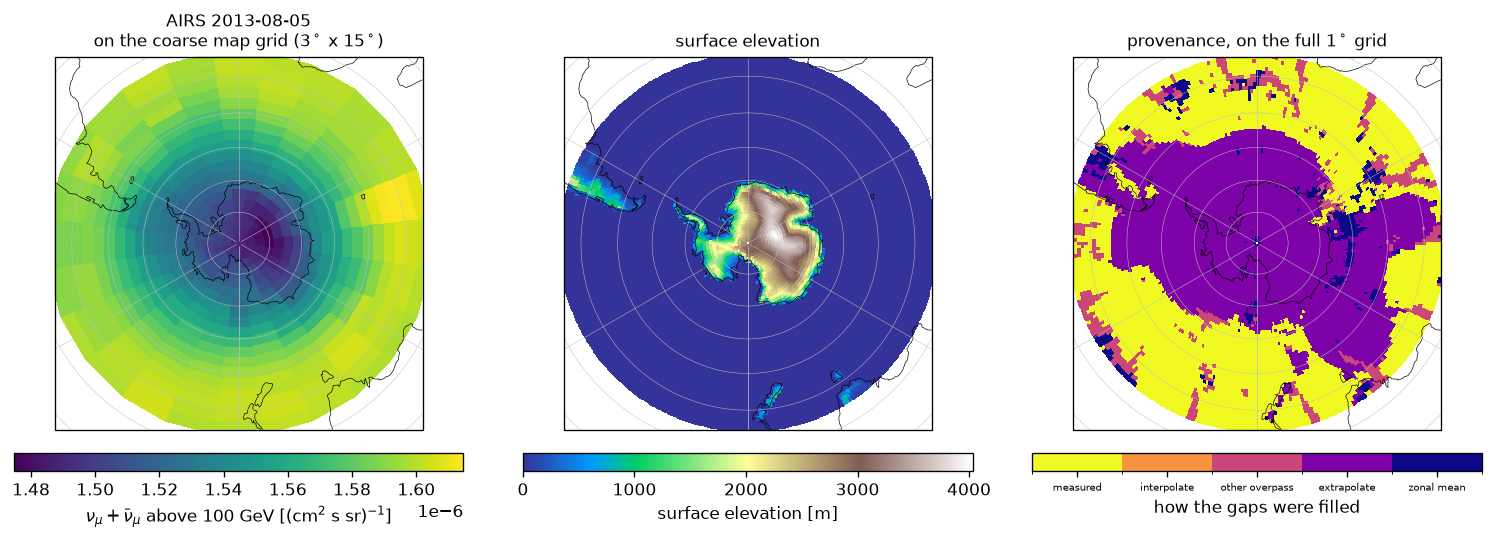

In [56]:
map_j = np.flatnonzero(lat)[::LAT_STRIDE]
map_i = np.arange(lon.size)[::LON_STRIDE]
map_lat, map_lon = lat[map_j], lon[map_i]


def rate_map(table):
    """Vertical numu+antinumu spectra at every map node, in one batched solve."""
    atmospheres = [
        dp.TabulatedAtmosphere(table, coord=(float(lon[i]), float(lat[j])),
                               surface_elevation_m=max(elevation_m[j, i], 0.0))
        for j in map_j for i in map_i]
    solution = mceq.solve_batch(
        conditions=[{"zenith_deg": 0.0, "density_model": a} for a in atmospheres])
    spectra = np.array([sum(solution.get_solution(n, k=k) for n in NU)
                        for k in range(solution.K)])
    return spectra.reshape(map_lat.size, map_lon.size, e_grid.size)


start = time.time()
spectra = rate_map(table)
today = rate(spectra)

fig = plt.figure(figsize=(13, 4.6), dpi=120)
ax = fig.add_subplot(1, 3, 1, projection=polar)
polar_map(ax, today, map_lat, map_lon, "viridis",
          rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV [(cm$^2$ s sr)$^{{-1}}$]", quant_cmap=False)
ax.set_title(f"AIRS {START_DATE}\non the coarse map grid "
             f"({LAT_STRIDE}$^\\circ$ x {LON_STRIDE}$^\\circ$)", fontsize=10)

ax = fig.add_subplot(1, 3, 2, projection=polar)
polar_map(ax, elevation_m, lat, lon, "terrain", "surface elevation [m]", quant_cmap=False)
ax.set_title("surface elevation", fontsize=10)

ax = fig.add_subplot(1, 3, 3, projection=polar)
mesh = polar_map(ax, column_source[first_key].astype(float), lat, lon,
                 "plasma_r", "how the gaps were filled")
mesh.colorbar.set_ticks(list(SOURCE_NAMES))
mesh.colorbar.set_ticklabels(list(SOURCE_NAMES.values()), fontsize=6)
ax.set_title("provenance, on the full 1$^\\circ$ grid", fontsize=10)

for ax in fig.axes[::2]:
    ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
fig.tight_layout()

In [57]:
# Load the rest of the week.  The animation that uses this is at the very
# end of the notebook, so the main line is not interrupted here.
week_dates = sorted({d for d, pas in table_files})
day_tables = {START_DATE: table}
week = [spectra]

start = time.time()
for date in week_dates[1:]:
    day_tables[date] = dp.AtmosphereTable.load_from_csv(table_files[(date, "A")])
    week.append(rate_map(day_tables[date]))
    print(f"  {date}  {time.time() - start:4.0f} s")
week = np.array(week)

week_rate = rate(week)
anomaly = 100 * (week_rate / week_rate.mean(axis=0) - 1)
swing = 100 * (week_rate.max(axis=0) / week_rate.min(axis=0) - 1)

# Is the motion weather, or the gap filling changing its mind between days?
always = np.array([column_source[(d, "A")][np.ix_(map_j, map_i)] == MEASURED
                   for d in week_dates]).all(axis=0)
print(f"\nday to day: {np.median(swing):.2f}% at the median node")
print(f"  measured every day ({always.mean():.0%} of nodes): "
      f"{np.median(swing[always]):.2f}%,  the rest: {np.median(swing[~always]):.2f}%")

  2013-08-06    35 s
  2013-08-07    67 s
  2013-08-08    97 s
  2013-08-09   127 s
  2013-08-10   158 s
  2013-08-11   188 s

day to day: 0.65% at the median node
  measured every day (4% of nodes): 0.58%,  the rest: 0.65%


## 9. What IceCube actually sees

IceCube's clean muon-neutrino sample comes **from below**.

**The catch is in the schematic below.** A neutrino arriving at 115° entered the
atmosphere about 50° of great circle away, over the Southern Ocean. That air is
nowhere near the detector, and ~29 K warmer. Tilting the pole's own column would
simply be wrong. `TabulatedLocationCentered` samples the table **where the
shower actually is**, averaging around the ring of impact points.

The schematic also explains something that otherwise looks backwards: the column
depth **falls** as the detector zenith grows. Further below the horizon means the
shower stands closer to *its own* vertical, so it crosses less air, not more.

(None,
 (np.float64(-1.63), np.float64(-0.3), np.float64(-0.3), np.float64(1.25)))

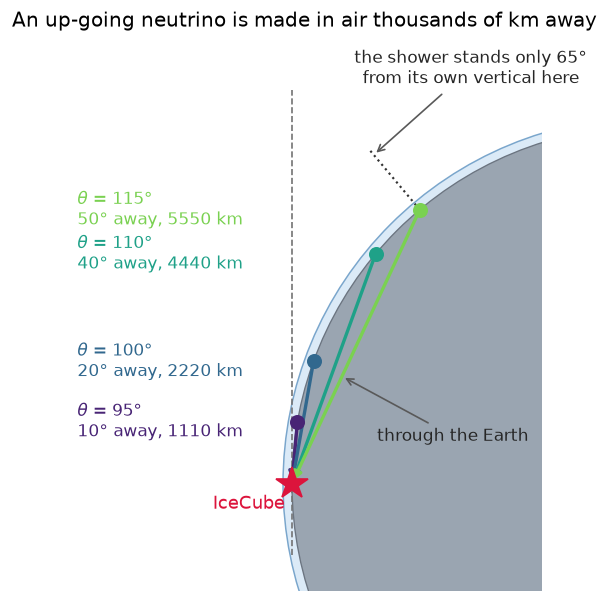

In [59]:
# Zoomed on the sector that matters.  The atmosphere shell is drawn thicker
# than it is; the entry points are placed on the surface, 2*theta - 180 degrees
# of great circle from the detector, which makes each drawn ray arrive at
# exactly its labelled zenith.
R, H = 1.0, 0.025
detector = np.array([-R, 0.0])

fig, ax = plt.subplots(figsize=(7.4, 6.0), dpi=120)
ax.add_patch(plt.Circle((0, 0), R + H, fc="#dbeaf7", ec="#7aa6cc", lw=0.9))
ax.add_patch(plt.Circle((0, 0), R, fc="#9aa5b1", ec="#6b7480", lw=0.8))
ax.plot([-R, -R], [-0.2, 1.1], "--", color="0.45", lw=1)

for theta, colour in zip([95, 100, 110, 115],
                         plt.cm.viridis(np.linspace(0.1, 0.8, 4))):
    away = 2 * theta - 180                      # degrees of great circle
    out = np.array([-np.cos(np.radians(away)), np.sin(np.radians(away))])
    ax.annotate("", xy=detector, xytext=R * out,
                arrowprops=dict(arrowstyle="-|>", color=colour, lw=2.0))
    ax.plot(*(R * out), "o", color=colour, ms=8, zorder=4)
    ax.text(-1.60, R * out[1], f"$\\theta$ = {theta}°\n{away}° away, "
            f"{away * 111:.0f} km", color=colour, fontsize=10, va="center")

# At the far end the shower stands much closer to its own vertical.
far = R * np.array([-np.cos(np.radians(50)), np.sin(np.radians(50))])
ax.plot(*np.c_[far, 1.22 * far], ":", color="0.2", lw=1.3)
ax.annotate("the shower stands only 65°\nfrom its own vertical here",
            xy=1.20 * far, xytext=(-0.50, 1.12), fontsize=10, color="0.15",
            ha="center", arrowprops=dict(arrowstyle="->", color="0.35"))
ax.annotate("through the Earth", xy=(-0.86, 0.30), xytext=(-0.55, 0.12),
            fontsize=10, color="0.15", ha="center",
            arrowprops=dict(arrowstyle="->", color="0.35"))

ax.plot(*detector, "*", color="crimson", ms=20, zorder=5)
ax.text(-R - 0.02, -0.07, "IceCube", ha="right", fontsize=11, color="crimson")
ax.set_title("An up-going neutrino is made in air thousands of km away",
             fontsize=12)
ax.set_xlim(-1.63, -0.30), ax.set_ylim(-0.30, 1.25)
ax.set_aspect("equal"), ax.axis("off")

### Sampling the table where the shower is

`TabulatedLocationCentered` binds the table to a *detector* rather than to a
grid point. For each zenith angle it finds the impact ring and reads the table
there. The printout below asks the geometry where the shower is, instead of
trusting a formula.

In [60]:
import datetime


def detector_atmosphere(table, date, extension="msis21"):
    """The atmosphere IceCube sees, sampled where the shower actually is."""
    return dp.TabulatedLocationCentered(
        table,
        detector_coord=(SITE_LON, SITE_LAT),
        surface_elevation_m=SITE_ELEVATION_M,   # ice surface above sea level
        depth_m=SITE_DEPTH_M,                   # detector below that surface
        n_azimuth=36,                           # samples for the ring average
        max_theta=180.0,                        # needed to accept zenith > 90
        top_extension=extension,                # NRLMSIS 2.1 above 1 hPa
        # doy dates the MSIS tail only.  The AIRS data is not touched by it.
        doy=datetime.date.fromisoformat(date).timetuple().tm_yday)


ic_atm = detector_atmosphere(table, START_DATE)

# Where is the shower?  Ask the geometry rather than trusting the formula.
print(f"{'zenith':>7s}{'impact lat':>12s}{'distance':>10s}{'column depth':>14s}")
impact_lat, depth = [], []
for zenith in ZENITH_BAND:
    ic_atm.set_theta(float(zenith), azimuth_deg=0.0)   # one azimuth: a point
    impact_lat.append(ic_atm.current_impact_latitude)
    ic_atm.set_theta(float(zenith))                    # the averaged ring
    depth.append(ic_atm.max_X)
    if zenith in ZENITH_BAND[::2]:               # print every second one
        print(f"{zenith:7.0f}{impact_lat[-1]:+12.1f}"
              f"{abs(impact_lat[-1] - SITE_LAT):7.0f} deg"
              f"{ic_atm.max_X:12.0f} g/cm^2")
impact_lat, depth = np.array(impact_lat), np.array(depth)

# What is the profile above the table worth?  Measure it: at 115 deg the whole
# slant column is small, so the unmeasured top is a big share of it.
tail = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": atmosphere}
    for atmosphere in (ic_atm, detector_atmosphere(table, START_DATE, "isothermal"))
    for z in (ZENITH_BAND[0], ZENITH_BAND[-1])])
msis_rate, iso_rate = (rate(np.array([
    sum(tail.get_solution(n, k=k) for n in NU) for k in pair]))
    for pair in ((0, 1), (2, 3)))
for k, zenith in enumerate((ZENITH_BAND[0], ZENITH_BAND[-1])):
    print(f"swapping the MSIS tail for an isothermal one at {zenith:.0f} deg: "
          f"{100 * (iso_rate[k] / msis_rate[k] - 1):+.2f}%")

 zenith  impact lat  distance  column depth
     90       -88.6      1 deg       15909 g/cm^2
     95       -80.1     10 deg       10779 g/cm^2
    100       -70.0     20 deg        5654 g/cm^2
    105       -60.0     30 deg        3854 g/cm^2
    110       -50.0     40 deg        2975 g/cm^2
    115       -40.0     50 deg        2433 g/cm^2
swapping the MSIS tail for an isothermal one at 90 deg: +0.01%
swapping the MSIS tail for an isothermal one at 115 deg: +0.86%


### The ring, drawn on the air it samples

Each coloured circle is one zenith angle's ring of impact points, on top of the
AIRS temperature near 16 km. The rings walk off the cold plateau and onto the
**warm Southern Ocean** — which is the whole reason a location-centred
atmosphere is needed.

the air at the far end of the band is 29 K warmer than the air over the detector


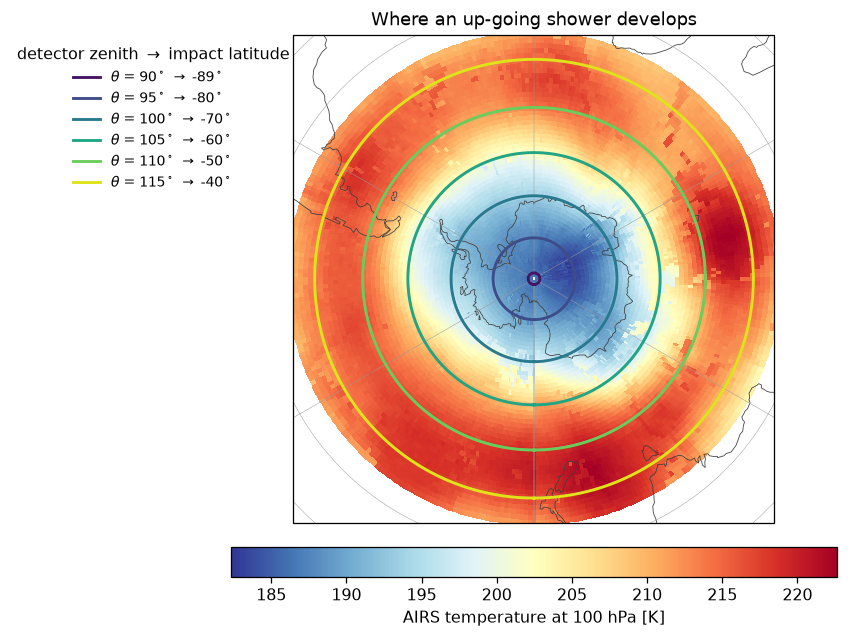

In [66]:
# The rings the azimuth average runs around, on the air they sample.
shown_T = map_temperature[first_key]

fig = plt.figure(figsize=(8.0, 6.8), dpi=115)
ax = fig.add_subplot(projection=polar)
ax.set_extent([-180, 180, -90, float(lat.max())], ccrs.PlateCarree())
mesh = ax.pcolormesh(np.append(lon, lon[0] + 360), lat,
                     np.concatenate([shown_T, shown_T[:, :1]], axis=1),
                     cmap="RdYlBu_r", shading="auto",
                     transform=ccrs.PlateCarree())
ax.coastlines(lw=0.5, color="0.25")
ax.gridlines(lw=0.3, color="0.6")
plt.colorbar(mesh, ax=ax, orientation="horizontal", pad=0.04, shrink=0.85,
             label=f"AIRS temperature at {p_hpa[MAP_LEVEL]:.0f} hPa [K]")

circle = np.linspace(-180, 180, 721)
shown = slice(None, None, 2)
for zenith, latitude, colour in zip(ZENITH_BAND[shown], impact_lat[shown],
                                    plt.cm.viridis(np.linspace(0.05, 0.95, 6))):
    ax.plot(circle, np.full_like(circle, latitude), color=colour, lw=1.8,
            transform=ccrs.Geodetic(),
            label=rf"$\theta$ = {zenith:.0f}$^\circ$ $\to$ {latitude:.0f}$^\circ$")
ax.plot(SITE_LON, SITE_LAT, "k*", ms=16, transform=ccrs.PlateCarree(), zorder=5)
# Outside the axes: on the map it covered the quadrant the rings run through.
ax.legend(loc="upper left", bbox_to_anchor=(-0.6, 1.0), fontsize=8.5,
          frameon=False, title="detector zenith $\\to$ impact latitude")
ax.set_title("Where an up-going shower develops", fontsize=11)

near, far = (np.nanmean(shown_T[np.argmin(np.abs(lat - x))])
             for x in (impact_lat[0], impact_lat[-1]))
print(f"the air at the far end of the band is {far - near:.0f} K warmer "
      f"than the air over the detector")

### The zenith scan

Three panels: the rate, how much air the path actually crosses, and what the
measurement is worth against climatology.

AIRS         band-integrated 8.026e-06 /cm^2/s
MSIS21       band-integrated 8.068e-06 /cm^2/s


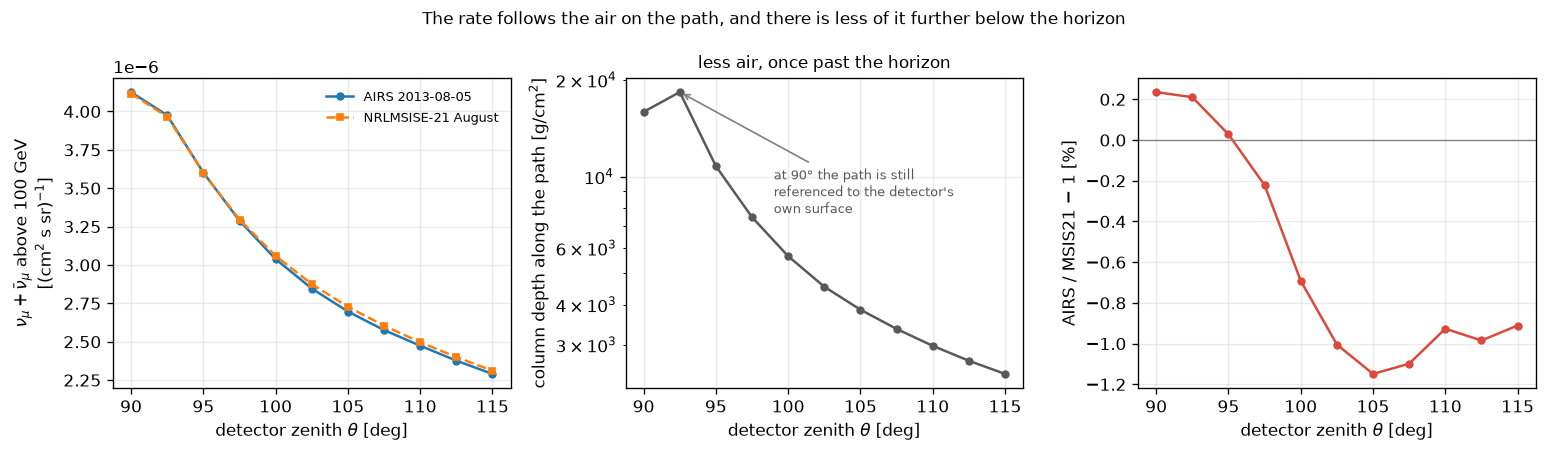

In [70]:
def integrate_band(theta_deg, flux_per_sr):
    """2*pi * int flux dcos(theta): per cm^2 s, over the band and all azimuths."""
    mu = np.cos(np.radians(theta_deg))
    order = np.argsort(mu)
    return 2 * np.pi * np.trapezoid(flux_per_sr[order], mu[order])


msis_ic = dp.MSIS21IceCubeCentered("SouthPole", "August")
solved = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": model}
    for model in (ic_atm, msis_ic) for z in ZENITH_BAND])
zenith_rate = rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                             for k in range(solved.K)])).reshape(2, -1)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for row, label, style in ((0, f"AIRS {START_DATE}", "-o"),
                          (1, f"NRLMSISE-21 August", "--s")):
    axes[0].plot(ZENITH_BAND, zenith_rate[row], style, ms=4, label=label)
axes[0].set_ylabel(rf"$\nu_\mu+\bar\nu_\mu$ above {edge:.0f} GeV"
                   "\n" r"[(cm$^2$ s sr)$^{-1}$]")
axes[0].legend(fontsize=8, frameon=False)

axes[1].semilogy(ZENITH_BAND, depth, "-o", ms=4, color="0.35")
axes[1].set_ylabel(r"column depth along the path [g/cm$^2$]")
axes[1].set_title("less air, once past the horizon", fontsize=10)
# Below the peak, not above it: at depth[1] * 1.1 the label lands on the title.
axes[1].annotate("at 90° the path is still\nreferenced to the detector's\nown surface",
                 xy=(92.5, depth[1]), xytext=(99, depth[1] * 0.42), fontsize=8,
                 color="0.35", arrowprops=dict(arrowstyle="->", color="0.5"))

axes[2].plot(ZENITH_BAND, 100 * (zenith_rate[0] / zenith_rate[1] - 1), "-o",
             ms=4, color="#d94a3d")
axes[2].axhline(0, color="0.5", lw=0.8)
axes[2].set_ylabel("AIRS / MSIS21 $-$ 1 [%]")
for ax in axes:
    ax.set_xlabel(r"detector zenith $\theta$ [deg]")
    ax.grid(alpha=0.25)
fig.suptitle("The rate follows the air on the path, and there is less of it "
             "further below the horizon", fontsize=10)
fig.tight_layout()

for row, label in ((0, "AIRS"), (1, "MSIS21")):
    print(f"{label:12s} band-integrated {integrate_band(ZENITH_BAND, zenith_rate[row]):.3e} /cm^2/s")

### Seven days, as IceCube would see them

The up-going band on the same seven days.

77 directions in 68 s


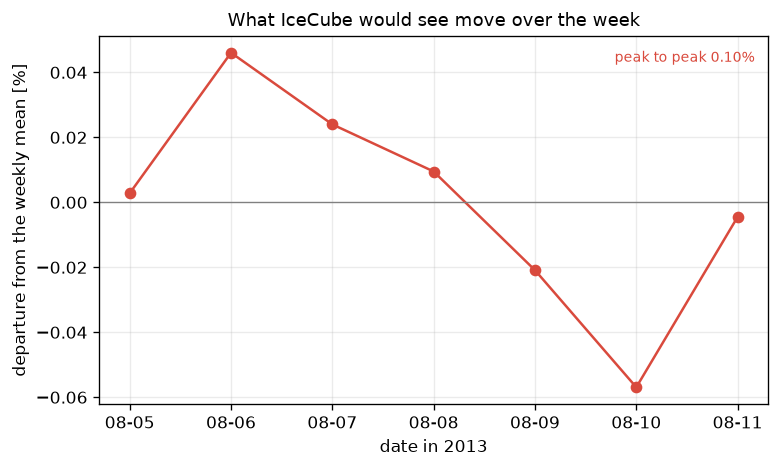

In [72]:
start = time.time()
solved = mceq.solve_batch(conditions=[
    {"zenith_deg": float(z), "density_model": detector_atmosphere(day_tables[d], d)}
    for d in week_dates for z in ZENITH_BAND])
band_rate = np.array([
    integrate_band(ZENITH_BAND, row) for row in
    rate(np.array([sum(solved.get_solution(n, k=k) for n in NU)
                   for k in range(solved.K)])).reshape(len(week_dates), -1)])
print(f"{solved.K} directions in {time.time() - start:.0f} s")

fig, ax = plt.subplots(figsize=(6.6, 4), dpi=120)
ax.plot(range(len(week_dates)), 100 * (band_rate / band_rate.mean() - 1), "-o",
        color="#d94a3d")
ax.axhline(0, color="0.5", lw=0.8)
ax.set_xticks(range(len(week_dates)), [d[5:] for d in week_dates])
ax.set_ylabel("departure from the weekly mean [%]")
ax.set_xlabel("date in 2013")
ax.grid(alpha=0.25)
ax.set_title("What IceCube would see move over the week", fontsize=11)
ax.text(0.98, 0.93, f"peak to peak "
        f"{100 * (band_rate.max() / band_rate.min() - 1):.2f}%",
        transform=ax.transAxes, ha="right", fontsize=8.5, color="#d94a3d")
fig.tight_layout()


## Extra: the whole week, animated

The motion is weather. For a smoother map, set `LAT_STRIDE` and `LON_STRIDE` to
1 at the top and re-run.

In [75]:
from matplotlib import animation
from IPython.display import HTML

fig = plt.figure(figsize=(6, 6.4), dpi=110)
ax = fig.add_subplot(projection=polar)
limit = np.percentile(np.abs(anomaly), 99)
mesh = polar_map(ax, anomaly[0], map_lat, map_lon, "RdBu_r",
                 "Rate departure from the weekly mean [%]", quant_cmap=False)
ax.plot(SITE_LON, SITE_LAT, "k*", ms=12, transform=ccrs.PlateCarree())
title = ax.set_title("")


def draw(step):
    closed = np.concatenate([anomaly[step], anomaly[step][:, :1]], axis=1)
    mesh.set_array(closed.ravel())
    title.set_text(week_dates[step])
    return mesh, title


ani = animation.FuncAnimation(fig, draw, frames=len(week_dates), interval=700)
plt.close(fig)
HTML(ani.to_jshtml())